# Impoprt Libraries

In [ ]:
import random
import my_data_manager as mdm # Replace with your own to load personalized data
import astro_utils as au
import cluster_utils as cu
import plot_maker as pm
import matplotlib.pyplot as plt

# Load Data

In [2]:
#Replace with your data
mocks_path = "SPLUS_clean_halos"
raw_cats = mdm.load_data(mocks_path)

print(raw_cats[0].head())

  # galaxyId haloId haloId_dor ra dec z_app log(m_200)
0  140005829421049.0 140005829198429.0 0.0 97.853...  
1  140005829372198.0 140005829198429.0 0.0 97.658...  
2  140005829372259.0 140005829198429.0 0.0 97.651...  
3  140005829372291.0 140005829198429.0 0.0 97.683...  
4  140005829372318.0 140005829198429.0 0.0 97.617...  


# Scrub Data

In [3]:
#Replace as necesary

cats = mdm.fix_columns(raw_cats)

members_count_threshold = 300
cats_subset = [cat for cat in cats if len(cat) > members_count_threshold]

sample_size = 30
cats_samples = random.sample(cats_subset, sample_size)

# Plot the Data

In [6]:
import importlib

importlib.reload(pm)

<module 'plot_maker' from '/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/plot_maker.py'>

[]

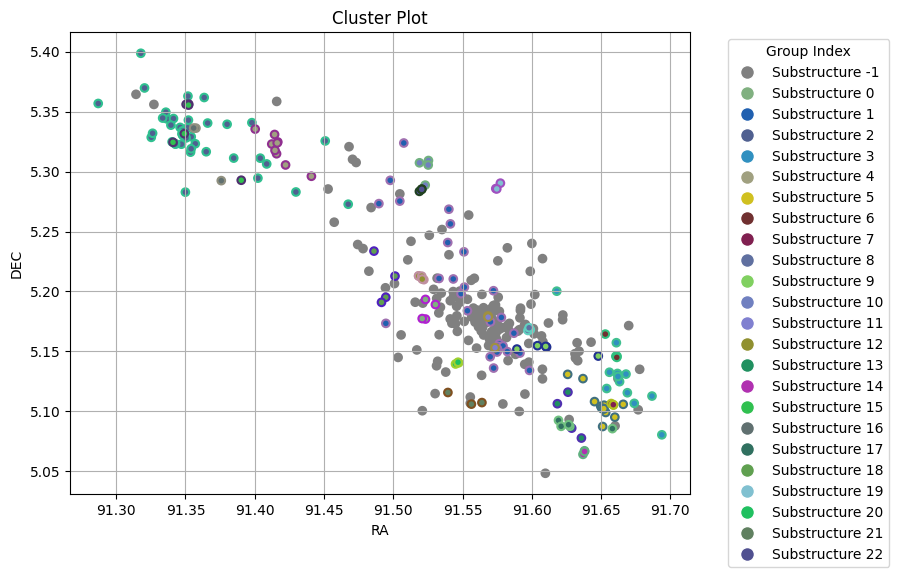

In [11]:
r_sample = cats_samples[random.randint(0, len(cats_samples)-1)]

X_data = r_sample.iloc[:,3].values
Y_data = r_sample.iloc[:,4].values
og_labels = r_sample.iloc[:,2].values

fig, ax = pm.cluster_plot_2D(X_data, Y_data, og_labels, x_axis_nature="RA", y_axis_nature="DEC", cluster_nature="Substructure")

plt.plot()
    

# Select Algorithms

In [ ]:
algorithms = {}


algorithms['GMM'] = clustering.run_GMM
algorithms['DBSCAN'] = clustering.run_DBSCAN
algorithms['HDBSCAN'] = clustering.run_HDBSCAN
algorithms['Optics'] = clustering.run_OPTICS
algorithms['Kmeans'] = clustering.run_Kmeans
algorithms['Aglomerative'] = clustering.run_Aglomerative_Clustering
algorithms['Affinity'] = clustering.run_Affinity_Propagation

# Set Parameters

In [ ]:
params = {
    "max_clusters" : 40,
    "covariance_type" : 'full',
    "min_cluster_size" : 5,
    "random_state" : 0,
    "min_eps" : 0.5,
    "max_eps" : np.inf,
    "linkage" : 'ward',
    "clustering_threshold" : 0.5,
    'key_point' : 'location'
}

# Run Algorithms

In [ ]:
alg_labels = {}

for alg in algorithms.keys():
    alg_labels[alg] = []

for sample in cats_samples:
    
    X_data = sample.iloc[:,3].values
    Y_data = sample.iloc[:,4].values
    
    data = np.vstack(X_data, Y_data)
    
    for alg in algorithms.keys():
        labels, probs, clusteres = algorithms[alg](data, params)
        alg_labels[alg].append(labels)
    
    
    

Add DS+ as benchmarking

In [ ]:
alg_labels["DS+"] = []

for sample in cats_samples:
    
    X_data = sample.iloc[:,3].values
    Y_data = sample.iloc[:,4].values
    Z_data = sample.iloc[:,5].values
    
    x_center = (min(X_data) + max(X_data))/2
    y_center = (min(Y_data) + max(Y_data))/2

    X_Kpc, Y_Kpc = to_kpc(X_data, Y_data, Z_data, x_center, y_center)
    
    Z_clus = np.mean(Z_data);
    V_data = to_vel(Z_data, Z_clus)

    galaxy_info, grouping, summary = milaDS.DSp_groups(X_data, Y_data, V_data, Z_clus)
    
    labels = np.array([row[8] for row in grouping]) #9th column corresponds to the group

    alg_labels[alg].append(labels)


Add CALSAGOS to compare

In [ ]:
alg_labels["CALSAGOS"] = []

# Select Metrics

In [ ]:
metrics = {}

metrics["distance"] = {}
metrics["neighbourhood completness"] = {}
metrics["neighbourhood purity"] = {}
metrics["neighbourhood f1_score"] = {}
metrics["membership completness"] = {}
metrics["membership purity"] = {}
metrics["membership f1_score"] = {}

for metric in metrics.keys():
    for alg in alg_labels.keys():
        metrics[metric][alg] = [] 

# Run Metrics

In [ ]:
for idx, sample in enumerate(cats_samples):
    
    X_data = sample.iloc[:,3].values
    Y_data = sample.iloc[:,4].values
    og_labels = sample.iloc[:,2].values
    
    data = np.vstack(X_data, Y_data)
    
    for alg in alg_labels.keys():
        
        distances = cu.calcualte_distances(data, og_labels, alg_labels[alg][idx])
        completeness, purity, f1_score = cu.calculate_overlap_metrics(data, og_labels, alg_labels[alg][idx])
        
        metrics["distance"][alg] = distances
        
        metrics["neighbourhood completness"][alg] = completeness
        metrics["neighbourhood purity"][alg] = purity
        metrics["neighbourhood f1_score"][alg] = f1_score
        
        completeness, purity, f1_score = cu.calculate_membership_metrics(og_labels, alg_labels[alg][idx])
        
        metrics["membership completness"][alg] = completeness
        metrics["membership purity"][alg] = purity
        metrics["membership f1_score"][alg] = f1_score
        

# Plot Metrics Results

In [ ]:
reliability_gradients = []

metric = "neighbourhood completness"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    
fig, ax = pm.gradients_plot(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

In [ ]:
reliability_gradients = []

metric = "neighbourhood purity"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    
fig, ax = pm.gradients_plot(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

In [ ]:
reliability_gradients = []

metric = "neighbourhood f1_score"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    
fig, ax = pm.gradients_plot(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

In [ ]:
reliability_gradients = []

metric = "membership completeness"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    
fig, ax = pm.gradients_plot(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

In [ ]:
reliability_gradients = []

metric = "membership purity"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    
fig, ax = pm.gradients_plot(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

In [ ]:
reliability_gradients = []

metric = "membership f1_score"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    
fig, ax = pm.gradients_plot(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

# Plot Clustering Results

# Save Data